# 2D problem with Jacobian assembly

In [1]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra

## Definitions

In [2]:
# constants
R_u = 8.314462618       # J/(mol*K)
M_H2 = 2.01588e-3       # kg/mol
R = R_u / M_H2       # J/(kg*K)
T = 300.0           # K
μ = 8.4e-6          # Pa*s = kg/(m*s)
# μ = 8.4e-1          # WROOOOONG, ONLY FOR TESTING PURPOSES, Pa*s = kg/(m*s)
μϵ = 1.0e-9         # Pa*s = kg/(m*s)  for stabilizing purposes, non-physical, should be as small as possible
C_a = 59.187        # s^-1
p_ref = 1.0e6       # 1MPA
ρ_sat = 7259.0      # kg/m^3
ρ_e = 7164.0        # kg/m^3    initial density solid
E_a = 21179.6       # J/mol
K = 1.0e-9          # m^2, permeability

ϵ = 0.4             # unitless, measure of porosity
A_hoffman = 10.7    # unitless  used for calculating p_eq, the equilibrium pressure, different for desorption
B_hoffman = 3704.6  # K used for calculating p_eq, the equilibrium pressure

# A = C_a * exp(-E_a/(R*T)) * (p_ref/(R*T))^A_t
A_a = C_a * exp(-E_a/(R_u*T))
p_eqa = p_ref * exp(A_hoffman-B_hoffman/T)

p_in = 4.0 * p_eqa
ρ_in = p_in / (R * T)
ρ_eq = p_eqa / (R * T)

τ = 1e-2 # boundary scale up term s

println("A_a = ", A_a, " s^-1")
println("p_eqa = ", p_eqa, " Pa")

A_a = 0.01215073059348989 s^-1
p_eqa = 192306.14595250844 Pa


In [3]:
# Time integration parameters
dt = 1e-4
dt_save = 1e-1
T1 = 3.0;

# spacial discretization parameters
L = 0.5     # length of the domain in x-direction
w = 0.2     # width of the domain in y-direction box is from (0, -w) to (L, w)
h1 = 0.1    # width of the inlet in y-direction. Inlet is from (0, -h1) to (0, h1)
Nx = 100
Ny = 100

hx = L / Nx
hy = 2*w / Ny

save_every = Int(round(dt_save / dt))  # = 100 steps
nsteps = Int(round(T1 / dt_save))


# name = "a. two dimensional";

30

## grid

In [4]:
# generates grid
grid = generate_grid(
    Quadrilateral, 
    (Nx, Ny), 
    Vec((0.0,-w)), 
    Vec((L,w))
)

# generate the same 
qr = QuadratureRule{RefQuadrilateral}(3)
fr = FacetQuadratureRule{RefQuadrilateral}(2)

# rho, rho_s, and v
ip_rho = Lagrange{RefQuadrilateral, 1}()
cellvalues_rho = CellValues(qr, ip_rho);

ip_rho_s = Lagrange{RefQuadrilateral, 1}()
cellvalues_rho_s = CellValues(qr, ip_rho_s);

ip_v = Lagrange{RefQuadrilateral, 1}()^2
cellvalues_v = CellValues(qr, ip_v);

# facet interpolation for the boundary conditions
ip_f = Lagrange{RefQuadrilateral, 1}()
fqr = FacetQuadratureRule{RefQuadrilateral}(1)
facetvalues = FacetValues(Float64, fqr, ip_f)
facetvalues_v = FacetValues(fqr, ip_v)          # because the velocity is a vector

#create left_slit
tol = 1e-8
left_slit = addfacetset!(
    grid,
    "left_slit",
    x -> abs(x[1]) < tol && -h1-tol <= x[2] <= h1+tol
)
    
addfacetset!(
    grid,
    "left_wall",
    x -> abs(x[1]) < tol &&
         abs(x[2]) >= h1 - tol
)

addfacetset!(
    grid,
    "right_wall",
    x -> abs(x[1] - L) < tol
)

addfacetset!(
    grid,
    "bottom_wall",
    x -> abs(x[2] + w) < tol
)

addfacetset!(
    grid,
    "top_wall",
    x -> abs(x[2] - w) < tol
)



# other boundaries
addfacetset!(
    grid,
    "no_slip_boundaries",
    x ->
        (
            abs(x[1]) < 1e-8 &&
            (x[2] <= -h1 || x[2] >= h1)
        ) ||                            # left boundary excluding the slit
        abs(x[1] - L) < 1e-8 ||         # right boundary
        abs(x[2] + w) < 1e-8 ||         # bottom boundary
        abs(x[2] - w) < 1e-8            # top boundary
)



Grid{2, Quadrilateral, Float64} with 10000 Quadrilateral cells and 10201 nodes

In [5]:
# degree of freedom handler
dh = DofHandler(grid)
add!(dh, :v,   ip_v)
add!(dh, :rho, ip_rho)
add!(dh, :rho_s, ip_rho_s)
close!(dh);

In [6]:
# # below only to find the dofs of the inlet boundary conditions, 
# ch_rho_left = ConstraintHandler(dh)

# dummy_rho = Dirichlet(
#     :rho,
#     left,
#     (x, t) -> 0.0,
# )

# add!(ch_rho_left, dummy_rho)
# close!(ch_rho_left)

# inlet_rho_dofs = copy(ch_rho_left.prescribed_dofs)

# ch_v_left = ConstraintHandler(dh)

# dummy_v = Dirichlet(
#     :v,
#     left,
#     (x, t) -> 0.0,
# )

# add!(ch_v_left, dummy_v)
# close!(ch_v_left)

# inlet_v_dofs = copy(ch_v_left.prescribed_dofs);

In [7]:
# linear constraint handler
ch_lin = ConstraintHandler(dh)

# τ = 0.01

# bottom/top: no normal velocity -> vy = 0
add!(
    ch_lin,
    Dirichlet(
        :v,
        union(getfacetset(grid, "bottom_wall"), getfacetset(grid, "top_wall")),
        (x,t) -> 0.0,
        2
    )
)

# left/right solid walls: no normal velocity -> vx = 0
add!(
    ch_lin,
    Dirichlet(
        :v,
        union(getfacetset(grid, "left_wall"), getfacetset(grid, "right_wall")),
        (x,t) -> 0.0,
        1
    )
)

function boundary(x, t)
    return ρ_eq+(ρ_in-ρ_eq) * (1.0 - exp(-t/τ))
end

function dboundary_dt(x, t)
    return -(ρ_in-ρ_eq)*exp(-t/τ)/τ
end

rho_inlet = Dirichlet(
    :rho,
    getfacetset(grid, "left_slit"),
    (x, t) -> ρ_eq + (ρ_in-ρ_eq) * (1.0 - exp(-t/τ))
)
# add!(ch_lin, no_slip)
add!(ch_lin, rho_inlet)
close!(ch_lin)

update!(ch_lin, 0.0)

In [8]:
# for debugging purpuses

const rho_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho)]
    for cell in CellIterator(dh)
]...)))

const v_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:v)]
    for cell in CellIterator(dh)
]...)));

const rho_s_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho_s)]
    for cell in CellIterator(dh)
]...)));

## Linear Matrices

$$(M_{\rho})_{ij}=\int \phi^i\phi^j\,dx$$

In [9]:
function doassemble_M_rho!(
    M_rho::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rho_s::CellValues,
    dh::DofHandler
    )

    # number of basis functions per field, initialize Me
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rho_s  = getnbasefunctions(cellvalues_rho_s)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(M_rho)
    rho_dofs = dof_range(dh, :rho)
    rhos_dofs  = dof_range(dh, :rho_s)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for rho
        cell_dofs = celldofs(cell)
        fill!(Me,0)
        
        # rho
        Ferrite.reinit!(cellvalues_rho, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)
            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q_point, i)
                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q_point, j)
                    # pim pam pet
                    Me[rho_dofs[i], rho_dofs[j]] += ϵ * psi_i * psi_j * dx
                end
            end
        end

        # rhos
        Ferrite.reinit!(cellvalues_rho_s, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho_s)
            dx = getdetJdV(cellvalues_rho_s, q_point)
            for i in 1:n_basefuncs_rho_s
                psi_i = shape_value(cellvalues_rho_s, q_point, i)
                for j in 1:n_basefuncs_rho_s
                    psi_j = shape_value(cellvalues_rho_s, q_point, j)
                    # pim pam pet
                    Me[rhos_dofs[i], rhos_dofs[j]] += (1-ϵ) * psi_i * psi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Me)
    end
    return M_rho
end


doassemble_M_rho! (generic function with 1 method)

$$D_{ij} = -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [10]:
function doassemble_D!(
    D::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    De = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(D)
    v_dofs = dof_range(dh, :v)
    
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(De,0)
        
        Ferrite.reinit!(cellvalues_v, cell)

        for q_point in 1:getnquadpoints(cellvalues_v)
            dx = getdetJdV(cellvalues_v, q_point)

            for i in 1:n_basefuncs_v
                dpsi_i = shape_gradient(cellvalues_v, q_point, i)

                for j in 1:n_basefuncs_v
                    dpsi_j = shape_gradient(cellvalues_v, q_point, j)

                    De[v_dofs[i], v_dofs[j]] += -μ * dpsi_i ⊡ dpsi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, De)
    end
    return D
end


doassemble_D! (generic function with 1 method)

$$D^p_{ij} = -\epsilon\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [11]:
function doassemble_Dp!(
    Dp::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Dpe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(Dp)
    rho_dofs = dof_range(dh, :rho)
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Dpe,0)
        
        Ferrite.reinit!(cellvalues_rho, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                dpsi_i = shape_gradient(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)

                    Dpe[rho_dofs[i], rho_dofs[j]] += -μϵ * dot(dpsi_i, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Dpe)
    end
    return Dp
end


doassemble_Dp! (generic function with 1 method)

$$P_{ij} = -RT\int\phi^i\partial_x\phi^j\,dx$$

In [12]:
function doassemble_P!(
    P::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    cellvalues_ρ:: CellValues,
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_ρ  = getnbasefunctions(cellvalues_ρ)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Pe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(P)
    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Pe,0)

        Ferrite.reinit!(cellvalues_v, cell)
        Ferrite.reinit!(cellvalues_ρ, cell)

        for q in 1:getnquadpoints(cellvalues_v)

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v

                phi_k = shape_value(cellvalues_v, q, k)

                for j in 1:n_basefuncs_ρ

                    dpsi_j = shape_gradient(cellvalues_ρ, q, j)

                    Pe[v_dofs[k], rho_dofs[j]] +=
                        -R*T * dot(phi_k, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Pe)
    end
    return P
end

doassemble_P! (generic function with 1 method)

$$
S_{ij} = \frac{\mu}{K}\int \phi^j\phi^i \, dx
$$

In [13]:
function doassemble_S!(
    S::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Se = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(S)
    v_dofs = dof_range(dh, :v)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Se,0)
        Ferrite.reinit!(cellvalues_v, cell)

        for q in 1:getnquadpoints(cellvalues_v)

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v

                phi_k = shape_value(cellvalues_v, q, k)

                for j in 1:n_basefuncs_v

                    phi_j = shape_value(cellvalues_v, q, j)

                    Se[v_dofs[k], v_dofs[j]] +=
                        -μ/K * dot(phi_k, phi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Se)
    end
    return S
end

doassemble_S! (generic function with 1 method)

## RHSParams

In [14]:
struct RHSparams{
    DH,
    CVR,
    CVS,
    CVV,
    FV,
    AO,
    CH
}
    A_a::Float64
    R::Float64
    T::Float64
    p_eqa::Float64
    rho_sat::Float64

    dh::DH

    cellvalues_rhog::CVR
    cellvalues_rhos::CVS
    cellvalues_v::CVV
    facetvalues::FV

    M::SparseMatrixCSC{Float64, Int64}      # mass matrix
    ML::SparseMatrixCSC{Float64, Int64}     # Linear part of mass Matrix

    N::Vector{Float64}                      # non-linear part of the rhs
    rhsL::SparseMatrixCSC{Float64, Int64}   # linear part of the rhs

    Jdu::SparseMatrixCSC{Float64, Int64}    # Matrix for the Jacobian wrt the time derivative of the state vector
    Ju::SparseMatrixCSC{Float64, Int64}     # Matrix for the Jacobian wrt the state vector

    assemble_operators!::AO                 # Complete assembly of the mass matrix, and rhs
    # assemble_mass!::AM                    # both redundant because I make them in the same loop in assemble_operators!
    # assemble_rhs!::AR

    ch_lin::CH                              # currently not yet implemented non linear 
end

## Assemble Operators

In [15]:
function assemble_operators!(
    u::Vector{Float64},
    params::RHSparams
)

    copyto!(params.M, params.ML)  # set M equal to the linear part of the mass matrix, which is constant in time
    params.N .= params.rhsL * u # This line computes the linear part of the right-hand side by multiplying the linear part of the right-hand side matrix (params.rhsL) with the solution vector (u). The result is stored in N, which represents the complete right-hand side vector for the system of equations.

    # now for the non-linear part:
    rhog_dofs = dof_range(params.dh, :rho)
    rhos_dofs = dof_range(params.dh, :rho_s)
    v_dofs    = dof_range(params.dh, :v)

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(params.cellvalues_v)
    n_basefuncs_rhog  = getnbasefunctions(params.cellvalues_rhog)
    
    first_cell = first(CellIterator(params.dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    assembler = start_assemble(params.M; fillzero=false) # do not fill zero since we already have the linear part in it!
    v_dofs = dof_range(params.dh, :v)
    rhog_dofs = dof_range(params.dh, :rho)

    for cell in CellIterator(params.dh)

        cell_dofs = celldofs(cell)

        rhog_local = view(u, cell_dofs[rhog_dofs])
        rhos_local = view(u, cell_dofs[rhos_dofs])
        v_local    = view(u, cell_dofs[v_dofs])

        Ferrite.reinit!(params.cellvalues_rhog, cell)
        Ferrite.reinit!(params.cellvalues_rhos, cell)
        Ferrite.reinit!(params.cellvalues_v, cell)

        fill!(Me,0)    

        for q in 1:getnquadpoints(params.cellvalues_rhog)

            dx = getdetJdV(params.cellvalues_rhog,q)

            # calculate the values of rhog, rhos, v, and ∂v at the quadrature point
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:length(rhog_local)
            )

            rhos_q = sum(
                rhos_local[j] *
                shape_value(params.cellvalues_rhos,q,j)
                for j in 1:length(rhos_local)
            )

            v_q = sum(
                v_local[j] *
                shape_value(params.cellvalues_v, q, j)
                for j in eachindex(v_local)
            )

            grad_v_q = sum(
                v_local[j] *
                shape_gradient(params.cellvalues_v, q, j)
                for j in eachindex(v_local)
            )

            # (v⋅∇)v = (∇v)v, which is a vector
            conv_v_q = grad_v_q ⋅ v_q

            # Convection term of rhog                               
            for k in 1:length(rhog_local)
                dψ = shape_gradient(params.cellvalues_rhog,q,k)
                params.N[cell_dofs[rhog_dofs[k]]] += dot(dψ, v_q) * rhog_q * dx
            end

            # Convection term of v
            for k in 1:length(v_local)
                ψ = shape_value(params.cellvalues_v,q,k)
                params.N[cell_dofs[v_dofs[k]]] += dot(ψ, conv_v_q) * rhog_q * dx        
            end

            # dot m =       A  *log(       R*       T*rhog  /       p_eqa)*(       rho_sat-rhos)
            mdot_q = params.A_a*log(params.R*params.T*rhog_q/params.p_eqa)*(params.rho_sat-rhos_q)
            for i in 1:length(rhog_local)
                ψ = shape_value(params.cellvalues_rhog,q,i)
                params.N[cell_dofs[rhog_dofs[i]]] -= ψ*mdot_q*dx
            end

            for i in 1:length(rhos_local)
                ψ = shape_value(params.cellvalues_rhos,q,i)
                params.N[cell_dofs[rhos_dofs[i]]] += ψ*mdot_q*dx
            end

            # now for the non-linear part of the mass matrix, which is only in the velocity equation
            for k in 1:n_basefuncs_v
                psi_k = shape_value(params.cellvalues_v, q, k)
                for i in 1:n_basefuncs_v
                    psi_i = shape_value(params.cellvalues_v, q, i)
                    Me[v_dofs[k], v_dofs[i]] += rhog_q*dot(psi_k,psi_i)*dx
                end
            end
        end
        assemble!(assembler, cell_dofs, Me)     

    end
end

assemble_operators! (generic function with 1 method)

## Assemble Jacobian

In [16]:
function jac!(J, du, u, params, gamma, t)

    # set the linear part of the Jacobian wrt the state vector, which is constant in time and is the derivative wrt the state vector
    params.Ju.nzval .= -params.rhsL.nzval   # set the linear part of the Jacobian wrt the state vector, which is constant in time and is the derivative wrt the state vector
    copyto!(params.Jdu, params.ML)          # set Jdu equal to the linear part of the mass matrix, which is constant in time and is the derivative wrt the time derivative of the state vector
    
    # now for the non-linear parts haha    
    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(params.cellvalues_v)
    n_basefuncs_rhog  = getnbasefunctions(params.cellvalues_rhog)
    n_basefuncs_rhos  = getnbasefunctions(params.cellvalues_rhos)
    
    
    # get the dof ranges for each field
    v_dofs = dof_range(params.dh, :v)
    rhog_dofs = dof_range(params.dh, :rho)
    rhos_dofs = dof_range(params.dh, :rho_s)
    
    # initialize the assemblers for the jacobian matrices
    assembler_Ju = start_assemble(params.Ju; fillzero=false)          # do not fill zero since we already have the linear part in it!
    assembler_Jdu = start_assemble(params.Jdu; fillzero=false)  # do not fill zero since we already have the linear part in it!
    
    # initialize the local Jacobian element matrices for each cell
    first_cell = first(CellIterator(params.dh))
    ndofs_cell = length(celldofs(first_cell))
    Jdue = zeros(ndofs_cell, ndofs_cell)
    Jue = zeros(ndofs_cell, ndofs_cell)
    
    # loop over all cells
    for cell in CellIterator(params.dh)    
        
        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)

        # get local values of this cell for rhog, rhos, v, and dv. In a view to avoid copying the data each cell loop
        rhog_local = view(u, cell_dofs[rhog_dofs])
        rhos_local = view(u, cell_dofs[rhos_dofs])
        v_local    = view(u, cell_dofs[v_dofs])
        dotv_local   = view(du, cell_dofs[v_dofs])

        # reinitialize the cell values for this cell
        Ferrite.reinit!(params.cellvalues_rhog, cell)
        Ferrite.reinit!(params.cellvalues_rhos, cell)
        Ferrite.reinit!(params.cellvalues_v, cell)

        fill!(Jdue,0)    
        fill!(Jue,0)

        for q in 1:getnquadpoints(params.cellvalues_v)

            # calculate the values of rhog, rhos, v, and ∂v at the quadrature point
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:length(rhog_local)
            )

            rhos_q = sum(
                rhos_local[j] *
                shape_value(params.cellvalues_rhos,q,j)
                for j in 1:length(rhos_local)
            )

            v_q = sum(
                v_local[j] *
                shape_value(params.cellvalues_v,q,j)
                for j in 1:length(v_local)
            )          

            dv_q = sum(
                v_local[j] *
                shape_gradient(params.cellvalues_v,q,j)
                for j in 1:length(v_local)
            )

            dotv_q = sum(
                dotv_local[j] *
                shape_value(params.cellvalues_v,q,j)
                for j in 1:length(dotv_local)
            )            

            dx = getdetJdV(params.cellvalues_v, q)

            # Non-linear terms for v
            for k in 1:length(v_local)
                ψk = shape_value(params.cellvalues_v,q,k)

                for i in 1:n_basefuncs_v
                    ψi = shape_value(params.cellvalues_v, q, i)
                    dψi = shape_gradient(params.cellvalues_v, q, i)

                    # non-linear convection term but then first the v part
                    Jue[v_dofs[k], v_dofs[i]] += rhog_q*((ψi ⋅ dv_q' + v_q ⋅ dψi') ⋅ ψk)*dx
                end

                for i in 1:n_basefuncs_rhog
                    ψi = shape_value(params.cellvalues_rhog, q, i) 
                    
                    # non-linear convection term but then the rhog part
                    Jue[v_dofs[k], rhog_dofs[i]] += ψi*((v_q ⋅ dv_q') ⋅ ψk)*dx

                    # non-linear mass matrix contribution
                    Jue[v_dofs[k], rhog_dofs[i]] += (dotv_q ⋅ ψk)*ψi*dx
                end
            end


            # dot m  =        A  *log(       R*       T*rhog  /       p_eqa)*(       rho_sat-rhos  )
            # mdot_q = params.A_a*log(params.R*params.T*rhog_q/params.p_eqa)*(params.rho_sat-rhos_q)
            dmdotdrhos_q = -params.A_a*log(params.R*params.T*rhog_q/params.p_eqa)
            dmdotdrhog_q = params.A_a*(params.rho_sat-rhos_q)/(rhog_q)

            # Non-linear terms for rhog
            for k in 1:n_basefuncs_rhog
                ψk = shape_value(params.cellvalues_rhog,q,k) 
                dψk = shape_gradient(params.cellvalues_rhog, q, k)

                for i in 1:n_basefuncs_v
                    ψi = shape_value(params.cellvalues_v, q, i) 
                    
                    # non-linear convection term but then the v part
                    Jue[rhog_dofs[k], v_dofs[i]] -= dot(dψk, ψi)*rhog_q*dx

                end
                for i in 1:n_basefuncs_rhog
                    ψi = shape_value(params.cellvalues_rhog, q, i) 
                    
                    # non-linear convection term but then the rhog part
                    Jue[rhog_dofs[k], rhog_dofs[i]] -= dot(dψk, v_q)*ψi*dx

                    # dmdotdrhog term
                    Jue[rhog_dofs[k], rhog_dofs[i]] += ψk*ψi*dmdotdrhog_q*dx
                end

                for i in 1:n_basefuncs_rhos
                    ψi = shape_value(params.cellvalues_rhos, q, i) 
                    
                    # dmdotdrhos term
                    Jue[rhog_dofs[k], rhos_dofs[i]] += ψk*ψi*dmdotdrhos_q*dx
                end
            end


            for k in 1:length(rhos_local)
                ψ = shape_value(params.cellvalues_rhos,q,k)
                
                for i in 1:n_basefuncs_rhog
                    ψi = shape_value(params.cellvalues_rhog, q, i) 
                    
                    # dmdotdrhog term
                    Jue[rhos_dofs[k], rhog_dofs[i]] -= ψ*ψi*dmdotdrhog_q*dx

                end
                for i in 1:n_basefuncs_rhos
                    ψi = shape_value(params.cellvalues_rhos, q, i) 
                    
                    # dmdotdrhos term
                    Jue[rhos_dofs[k], rhos_dofs[i]] -= ψ*ψi*dmdotdrhos_q*dx
                end
            end

            for k in 1:n_basefuncs_v
                psi_k = shape_value(params.cellvalues_v, q, k)
                for i in 1:n_basefuncs_v
                    psi_i = shape_value(params.cellvalues_v, q, i)

                    # the only non-linear part of the Jacobian wrt du is in (ρdv)
                    Jdue[v_dofs[k], v_dofs[i]] += rhog_q*dot(psi_k, psi_i)*dx
                end
            end


        end
        assemble!(assembler_Jdu, cell_dofs, Jdue)
        assemble!(assembler_Ju, cell_dofs, Jue)
    end
    
    # PDE rows replaced by algebraic BCs 
    # BC: u[dof]-value
    # -> no du dependence
    # -> Ju[dof,dof] = 1
    for dof in params.ch_lin.prescribed_dofs
        
        params.Jdu[dof, :] .= 0.0

        params.Ju[dof, :] .= 0.0
        params.Ju[dof, dof] = 1.0        
    end
   
    # J = Ju + gamma * Jdu
    copyto!(J, params.Ju)
    @. J.nzval += gamma * params.Jdu.nzval

    return
end;

## State vectors and parameters

In [17]:
# State vectors
ndofs_total = ndofs(dh)
u      = zeros(ndofs_total)
du     = similar(u)
du    .= 0.0
N      = similar(u)

# Initialization of matrices
# Assemble linear matrices
ML    = allocate_matrix(dh)
M     = allocate_matrix(dh)
D     = allocate_matrix(dh)
Dp    = allocate_matrix(dh)
P     = allocate_matrix(dh)
S     = allocate_matrix(dh)
rhsL  = allocate_matrix(dh)
J_proto = allocate_matrix(dh)

# Jacobian matrices
Jdu   = allocate_matrix(dh)
Ju    = allocate_matrix(dh)

doassemble_M_rho!(ML, cellvalues_rho, cellvalues_rho_s, dh)
doassemble_D!(D, cellvalues_v, dh)
doassemble_Dp!(Dp, cellvalues_rho, dh)
doassemble_P!(P, cellvalues_v, cellvalues_rho, dh)
doassemble_S!(S, cellvalues_v, dh)

# Linear parts of rhs
rhsL.nzval .= P.nzval .+ D.nzval .+ Dp.nzval .+ S.nzval

# Initial condition
apply_analytical!(u, dh, :rho, x -> p_eqa/(R*T))
apply_analytical!(u, dh, :rho_s, x -> ρ_e)
apply_analytical!(u, dh, :v,   x -> Vec(0.0, 0.0))

# Initial BC application
update!(ch_lin, 0.0)
apply!(u, ch_lin);

In [18]:
params = RHSparams(
    A_a, 
    R, 
    T, 
    p_eqa, 
    ρ_sat, 
    dh, 
    cellvalues_rho, 
    cellvalues_rho_s, 
    cellvalues_v,
    facetvalues,
    M,
    ML,
    N,
    rhsL,
    Jdu,
    Ju,
    assemble_operators!,
    ch_lin,
)

RHSparams{DofHandler{2, Grid{2, Quadrilateral, Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, VectorizedInterpolation{2, RefQuadrilateral, 1, Lagrange{RefQuadrilateral, 1}}, Matrix{Vec{2, Float64}}, Matrix{Tensor{2, 2, Float64, 4}}, Matrix{Tensor{2, 2, Float64, 4}}, Nothing, Nothing

In [19]:
function res!(res, du, u, params, t)

    params.assemble_operators!(u, params)

    mul!(res, params.M, du)      # res = M*du
    res .-= params.N

    # linear constraints
    update!(params.ch_lin, t)
    for k in 1:length(params.ch_lin.prescribed_dofs)

        dof = params.ch_lin.prescribed_dofs[k]
        value = params.ch_lin.inhomogeneities[k]

        res[dof] = u[dof] - value
        
    end
end


res! (generic function with 1 method)

## Initial state

In [20]:
params.assemble_operators!(u, params)

A0 = copy(params.M)
b0 = copy(params.N)

# ramped rho inlet. Derivative at inlet t=0
drho_bc_dt = (ρ_in - ρ_eq) / τ

# no-slip velocity BCs: prescribed velocity is constant zero
for k in 1:length(params.ch_lin.prescribed_dofs)
    dof = params.ch_lin.prescribed_dofs[k]

    A0[dof, :] .= 0.0
    A0[dof, dof] = 1.0

    if dof in v_global
        b0[dof] = 0.0
    else
        b0[dof] = drho_bc_dt
    end
end


# for dof in rho_inlet_dofs
#     A0[dof, :] .= 0.0
#     A0[dof, dof] = 1.0
#     b0[dof] = drho_bc_dt
# end

du .= A0 \ b0;

## Problem Solve

In [21]:
using DifferentialEquations, Sundials

In [22]:
using BenchmarkTools

In [23]:
T_end = 200.0 # 10.0
T_save = T_end*1e-2

2.0

In [24]:
differential_vars = trues(length(u))

for dof in ch_lin.prescribed_dofs
    differential_vars[dof] = false
end

tspan = (0.0, T_end)

(0.0, 200.0)

In [25]:
dae_f = DAEFunction(
    res!;
    jac = jac!,
    jac_prototype = J_proto
)

prob = DAEProblem(
    dae_f,
    du,
    u,
    tspan,
    params;
    differential_vars = differential_vars
)

DAEProblem with uType Vector{Float64} and tType Float64. In-place: true
timespan: (0.0, 200.0)
u0: 40804-element Vector{Float64}:
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.15541838814031642
    0.15541838814031642
    0.15541838814031642
    0.15541838814031642
 7164.0
    ⋮
    0.0
    0.0
    0.15541838814031642
 7164.0
    0.0
    0.0
    0.15541838814031642
 7164.0
    0.0
    0.0
    0.15541838814031642
 7164.0
du0: 40804-element Vector{Float64}:
  0.0
  0.0
  2.2353135881380032e-8
  0.0
 -6.442756974302661e-9
  6.489078062358345e-8
  0.0
  3.710447717082387e-8
 -4.678492850710662e-13
  1.2624590215774806e-13
 -2.5080355941594295e-13
  9.383235256765491e-13
 -6.175323429996226e-16
  ⋮
  1.4626589259250109e-8
  0.0
  3.444218582460989e-16
 -2.296228179852511e-16
 -3.654655761501464e-9
  0.0
  4.519686365947281e-16
 -3.0130209134641424e-16
  0.0
  0.0
  5.06635138683899e-17
 -3.3791401312928793e-17

In [26]:
sol = solve(
    prob,
    IDA(linear_solver = :KLU);
    reltol = 1e-6,
    abstol = 1e-6
)

retcode: Success
Interpolation: 3rd order Hermite
t: 1963-element Vector{Float64}:
   0.0
   5.2678789148242204e-9
   1.580363674447266e-8
   2.63393945741211e-8
   3.687515240376954e-8
   5.794666806306642e-8
   7.90181837223633e-8
   1.0008969938166019e-7
   1.4223273070025397e-7
   1.8437576201884775e-7
   2.6866182465603525e-7
   3.529478872932228e-7
   4.3723394993041035e-7
   ⋮
 161.79013828160438
 165.58648620383548
 169.38283412606657
 173.17918204829766
 176.97552997052875
 180.77187789275985
 184.56822581499094
 188.36457373722203
 192.16092165945312
 195.95726958168422
 199.7536175039153
 200.0
u: 1963-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.15541838814031642, 0.15541838814031642  …  0.15541838814031642, 7164.0, 0.0, 0.0, 0.15541838814031642, 7164.0, 0.0, 0.0, 0.15541838814031642, 7164.0]
 [0.0, 0.0, 1.1780138323797204e-16, 0.0, -3.403520714601677e-17, 3.4121067860164406e-16, 0.0, 1.9790718816454847e-16, 0.15541838814031642, 0.15541838814

In [27]:
sol.t[end]-sol.t[end-1]

0.2463824960846921

In [28]:
sol.alg

IDA{:KLU, Nothing, Nothing}(0, 0, 0, 5, 7, 0.33, 3, 10, 0.0033, 5, 4, 10, 100, true, false, nothing, nothing)

In [444]:
using Serialization

t_saved = sol.t
u_saved = sol.u

t_end_saved = sol.t[end]
u_end_saved = copy(sol.u[end])
du_end_saved = copy(sol(t_end_saved, Val{1}))

backup = (
    t      = t_saved,
    u      = u_saved,
    t_end  = t_end_saved,
    u_end  = u_end_saved,
    du_end = du_end_saved,
)

open("solution_80x80_backup.jls", "w") do io
    serialize(io, backup)
end

In [29]:
sol.destats

SciMLBase.DEStats
Number of function 1 evaluations:                  2951
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    180
Number of linear solves:                           0
Number of Jacobians created:                       180
Number of nonlinear solver iterations:             2951
Number of nonlinear solver convergence failures:   75
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                0
Number of accepted steps:                          1952
Number of rejected steps:                          10

## Plotting/animating

In [30]:
using Plots
using LinearAlgebra
using UniformStreamlines

In [105]:
xs = [node.x[1] for node in getnodes(grid)]
ys = [node.x[2] for node in getnodes(grid)]

# Find global plotting limits first
rho_min  = Inf
rho_max  = -Inf
rhos_min = Inf
rhos_max = -Inf

for uk in sol.u
    rho_nodes  = evaluate_at_grid_nodes(dh, uk, :rho)
    rhos_nodes = evaluate_at_grid_nodes(dh, uk, :rho_s)

    rho_min  = min(rho_min, minimum(rho_nodes))
    rho_max  = max(rho_max, maximum(rho_nodes))

    rhos_min = min(rhos_min, minimum(rhos_nodes))
    rhos_max = max(rhos_max, maximum(rhos_nodes))
end

anim = @animate for k in eachindex(sol.t)

    rho_nodes  = evaluate_at_grid_nodes(dh, sol.u[k], :rho)
    rhos_nodes = evaluate_at_grid_nodes(dh, sol.u[k], :rho_s)

    p1 = scatter(
        xs,
        ys,
        marker_z = rho_nodes,
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = (rho_min, rho_max),
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title = "ρ_g at t = $(round(1000sol.t[k], digits=5)) ms",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w),
    )

    p2 = scatter(
        xs,
        ys,
        marker_z = rhos_nodes,
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = (rhos_min, rhos_max),
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title = "ρ_s",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w),
    )

    plot(p1, p2, layout=(2,1), size=(800,600))
end


Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_pEqB0S", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000092.png", "000093.png", "000094.png", "000095.png", "000096.png", "000097.png", "000098.png", "000099.png", "000100.png", "000101.png"])

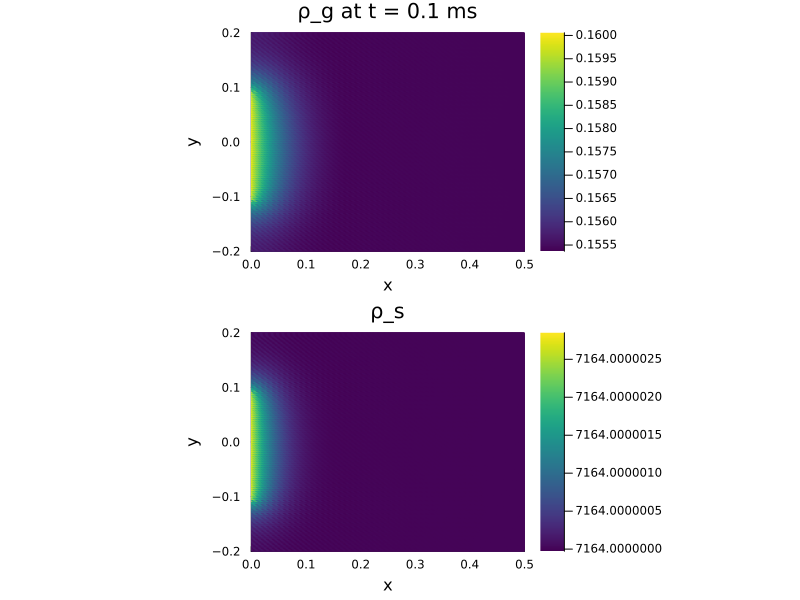

In [34]:
xs = [node.x[1] for node in getnodes(grid)]
ys = [node.x[2] for node in getnodes(grid)]

# Find global plotting limits first
rho_min  = Inf
rho_max  = -Inf
rhos_min = Inf
rhos_max = -Inf

t = 1e-4

ut = sol(t)

rho_nodes  = evaluate_at_grid_nodes(dh, ut, :rho)
rhos_nodes = evaluate_at_grid_nodes(dh, ut, :rho_s)

rho_min  = min(rho_min, minimum(rho_nodes))
rho_max  = max(rho_max, maximum(rho_nodes))

rhos_min = min(rhos_min, minimum(rhos_nodes))
rhos_max = max(rhos_max, maximum(rhos_nodes))


rho_nodes  = evaluate_at_grid_nodes(dh, sol(t), :rho)
rhos_nodes = evaluate_at_grid_nodes(dh, sol(t), :rho_s)

p1 = scatter(
    xs,
    ys,
    marker_z = rho_nodes,
    markersize = 6,
    markerstrokewidth = 0,
    color = :viridis,
    colorbar = true,
    clims = (rho_min, rho_max),
    xlabel = "x",
    ylabel = "y",
    aspect_ratio = :equal,
    title = "ρ_g at t = $(round(1000t, digits=5)) ms",
    legend = false,
    xlims = (0, L),
    ylims = (-w, w),
)

p2 = scatter(
    xs,
    ys,
    marker_z = rhos_nodes,
    markersize = 6,
    markerstrokewidth = 0,
    color = :viridis,
    colorbar = true,
    clims = (rhos_min, rhos_max),
    xlabel = "x",
    ylabel = "y",
    aspect_ratio = :equal,
    title = "ρ_s",
    legend = false,
    xlims = (0, L),
    ylims = (-w, w),
)

p = plot(p1, p2, layout=(2,1), size=(800,600))

In [35]:
savefig(p, "b. jacobian\\model_5_resutl.png")

"c:\\Users\\noudh\\uni\\MEP\\Model 5\\b. jacobian\\model_5_resutl.png"

In [31]:
sol.t[end]

100.0

[ Info: Saved animation to c:\Users\noudh\uni\MEP\Model 5\b. jacobian\high_res_new_short2.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\Model 5\\b. jacobian\\high_res_new_short2.gif")
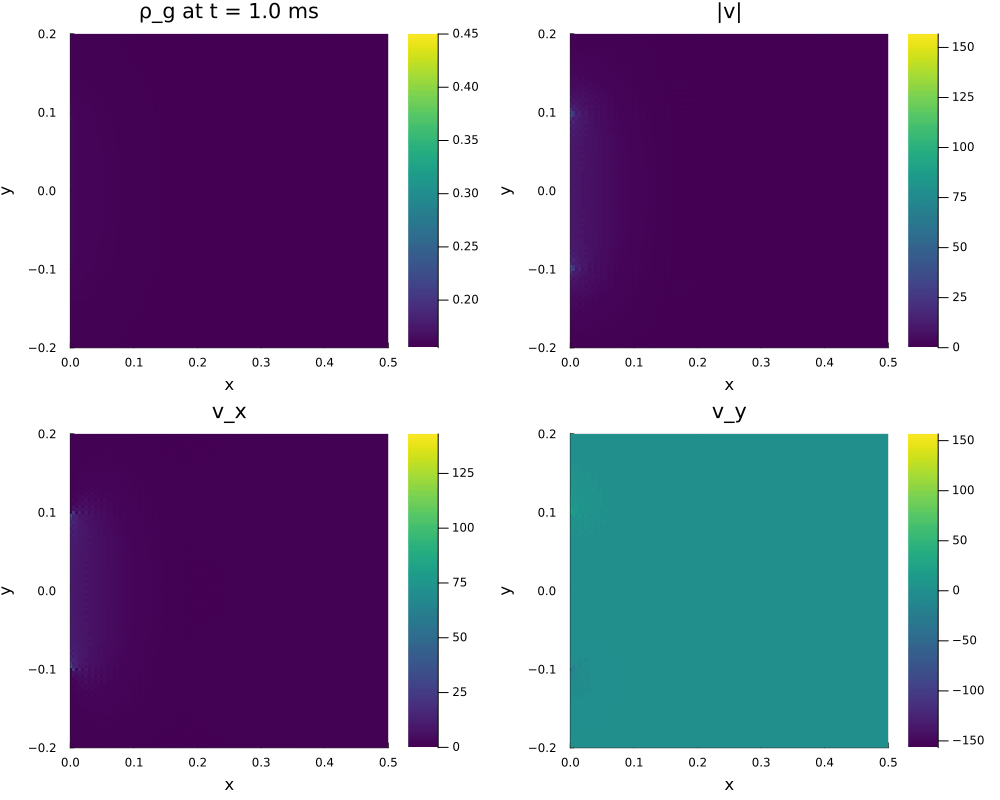

In [41]:
foldername = "b. jacobian"
gif(anim, joinpath(foldername, "high_res_new_short2.gif"), fps=20)

In [40]:
K = length(sol.t)

# coordinates of grid nodes
xs = [node.x[1] for node in getnodes(grid)]
ys = [node.x[2] for node in getnodes(grid)]

# structured plotting coordinates
xplot = collect(range(0.0, L, length=Nx+1))
yplot = collect(range(-w, w, length=Ny+1))

# helper to map nodal values to structured matrix
function nodal_matrix(grid, values, Nx, Ny, L, w)
    Z = zeros(Ny+1, Nx+1)

    hx = L / Nx
    hy = 2w / Ny

    for (node, value) in zip(getnodes(grid), values)
        ix = round(Int, node.x[1] / hx) + 1
        iy = round(Int, (node.x[2] + w) / hy) + 1
        Z[iy, ix] = value
    end

    return Z
end

# helper for safe color limits
function safe_clims(vmin, vmax)
    if isapprox(vmin, vmax; rtol=1e-8, atol=1e-11)
        δ = max(abs(vmin), 1.0) * 1e-6
        return (vmin - δ, vmax + δ)
    else
        return (vmin, vmax)
    end
end

# compute global plotting limits
rho_min  = Inf
rho_max  = -Inf

vmag_min = Inf
vmag_max = -Inf

vx_min = Inf
vx_max = -Inf

vy_min = Inf
vy_max = -Inf

for k in 1:100

    t = k/10000
    uk = sol(t)
    rho_nodes = evaluate_at_grid_nodes(dh, uk, :rho)
    v_nodes   = evaluate_at_grid_nodes(dh, uk, :v)

    vx_nodes   = [v[1] for v in v_nodes]
    vy_nodes   = [v[2] for v in v_nodes]
    vmag_nodes = [norm(v) for v in v_nodes]

    rho_min  = min(rho_min, minimum(rho_nodes))
    rho_max  = max(rho_max, maximum(rho_nodes))

    vmag_min = min(vmag_min, minimum(vmag_nodes))
    vmag_max = max(vmag_max, maximum(vmag_nodes))

    vx_min = min(vx_min, minimum(vx_nodes))
    vx_max = max(vx_max, maximum(vx_nodes))

    vy_min = min(vy_min, minimum(vy_nodes))
    vy_max = max(vy_max, maximum(vy_nodes))
end

rho_clims  = safe_clims(rho_min, rho_max)
vmag_clims = safe_clims(vmag_min, vmag_max)
vx_clims   = safe_clims(vx_min, vx_max)
vy_clims   = safe_clims(vy_min, vy_max)

anim = @animate for k in 1:100 # length(sol.t)

    t = k/10000
    rho_nodes = evaluate_at_grid_nodes(dh, sol(t), :rho)
    v_nodes   = evaluate_at_grid_nodes(dh, sol(t), :v)

    vx_nodes   = [v[1] for v in v_nodes]
    vy_nodes   = [v[2] for v in v_nodes]
    vmag_nodes = [norm(v) for v in v_nodes]

    # convert nodal vectors to structured matrices
    rho_mat  = nodal_matrix(grid, rho_nodes,  Nx, Ny, L, w)
    vmag_mat = nodal_matrix(grid, vmag_nodes, Nx, Ny, L, w)
    vx_mat   = nodal_matrix(grid, vx_nodes,   Nx, Ny, L, w)
    vy_mat   = nodal_matrix(grid, vy_nodes,   Nx, Ny, L, w)

    # rho_g
    p1 = heatmap(
        xplot,
        yplot,
        rho_mat,
        color = :viridis,
        colorbar = true,
        clims = rho_clims,
        xlabel = "x",
        ylabel = "y",
        # aspect_ratio = :equal,
        title = "ρ_g at t = $(round(k, digits=5)) ms",
        xlims = (0, L),
        ylims = (-w, w),
    )

    # |v|
    p2 = heatmap(
        xplot,
        yplot,
        vmag_mat,
        color = :viridis,
        colorbar = true,
        clims = vmag_clims,
        xlabel = "x",
        ylabel = "y",
        # aspect_ratio = :equal,
        title = "|v|",
        xlims = (0, L),
        ylims = (-w, w),
    )

    # vx
    p3 = heatmap(
        xplot,
        yplot,
        vx_mat,
        color = :viridis,
        colorbar = true,
        clims = vx_clims,
        xlabel = "x",
        ylabel = "y",
        # aspect_ratio = :equal,
        title = "v_x",
        xlims = (0, L),
        ylims = (-w, w),
    )

    # vy
    p4 = heatmap(
        xplot,
        yplot,
        vy_mat,
        color = :viridis,
        colorbar = true,
        clims = vy_clims,
        xlabel = "x",
        ylabel = "y",
        # aspect_ratio = :equal,
        title = "v_y",
        xlims = (0, L),
        ylims = (-w, w),
    )

    plot(
        p1,
        p2,
        p3,
        p4,
        layout = (2, 2),
        size = (1000, 800),
    )

    println("Frame $(k) of $(100)")
end

Frame 1 of 100
Frame 2 of 100
Frame 3 of 100
Frame 4 of 100
Frame 5 of 100
Frame 6 of 100
Frame 7 of 100
Frame 8 of 100
Frame 9 of 100
Frame 10 of 100
Frame 11 of 100
Frame 12 of 100
Frame 13 of 100
Frame 14 of 100
Frame 15 of 100
Frame 16 of 100
Frame 17 of 100
Frame 18 of 100
Frame 19 of 100
Frame 20 of 100
Frame 21 of 100
Frame 22 of 100
Frame 23 of 100
Frame 24 of 100
Frame 25 of 100
Frame 26 of 100
Frame 27 of 100
Frame 28 of 100
Frame 29 of 100
Frame 30 of 100
Frame 31 of 100
Frame 32 of 100
Frame 33 of 100
Frame 34 of 100
Frame 35 of 100
Frame 36 of 100
Frame 37 of 100
Frame 38 of 100
Frame 39 of 100
Frame 40 of 100
Frame 41 of 100
Frame 42 of 100
Frame 43 of 100
Frame 44 of 100
Frame 45 of 100
Frame 46 of 100
Frame 47 of 100
Frame 48 of 100
Frame 49 of 100
Frame 50 of 100
Frame 51 of 100
Frame 52 of 100
Frame 53 of 100
Frame 54 of 100
Frame 55 of 100
Frame 56 of 100
Frame 57 of 100
Frame 58 of 100
Frame 59 of 100
Frame 60 of 100
Frame 61 of 100
Frame 62 of 100
Frame 63 of 100
F

Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_LGfFIE", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000091.png", "000092.png", "000093.png", "000094.png", "000095.png", "000096.png", "000097.png", "000098.png", "000099.png", "000100.png"])

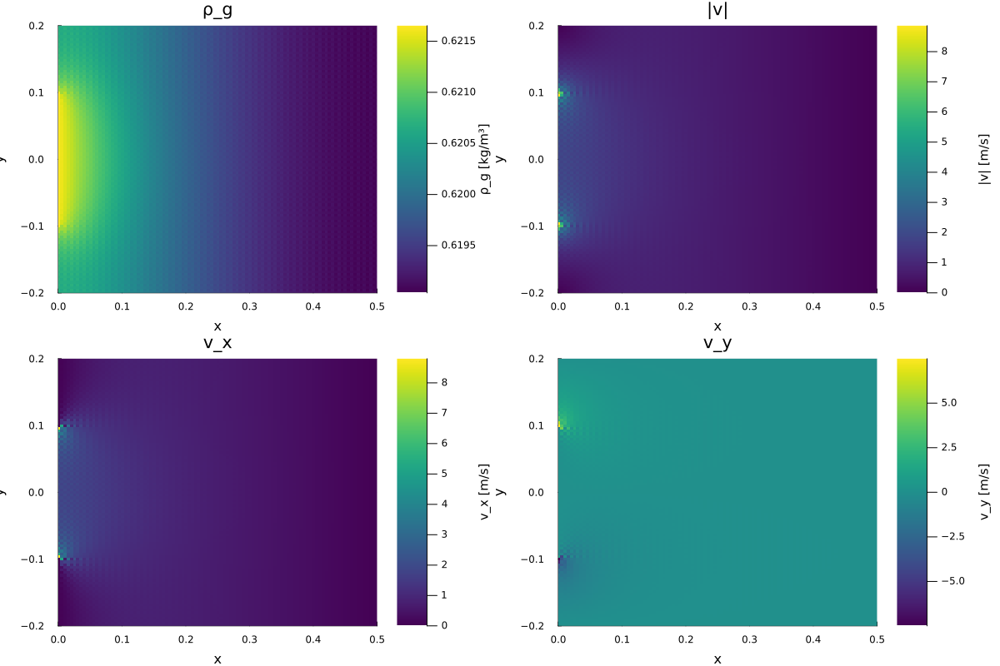

In [44]:
t = 1e-1

# coordinates of grid nodes
xs = [node.x[1] for node in getnodes(grid)]
ys = [node.x[2] for node in getnodes(grid)]

# structured plotting coordinates
xplot = collect(range(0.0, L, length=Nx+1))
yplot = collect(range(-w, w, length=Ny+1))

# helper to map nodal values to structured matrix
function nodal_matrix(grid, values, Nx, Ny, L, w)
    Z = zeros(Ny+1, Nx+1)

    hx = L / Nx
    hy = 2w / Ny

    for (node, value) in zip(getnodes(grid), values)
        ix = round(Int, node.x[1] / hx) + 1
        iy = round(Int, (node.x[2] + w) / hy) + 1
        Z[iy, ix] = value
    end

    return Z
end

# helper for safe color limits
function safe_clims(vmin, vmax)
    if isapprox(vmin, vmax; rtol=1e-8, atol=1e-11)
        δ = max(abs(vmin), 1.0) * 1e-6
        return (vmin - δ, vmax + δ)
    else
        return (vmin, vmax)
    end
end

# compute global plotting limits
rho_min  = Inf
rho_max  = -Inf

vmag_min = Inf
vmag_max = -Inf

vx_min = Inf
vx_max = -Inf

vy_min = Inf
vy_max = -Inf

uk = sol(t)
rho_nodes = evaluate_at_grid_nodes(dh, uk, :rho)
v_nodes   = evaluate_at_grid_nodes(dh, uk, :v)

vx_nodes   = [v[1] for v in v_nodes]
vy_nodes   = [v[2] for v in v_nodes]
vmag_nodes = [norm(v) for v in v_nodes]

rho_min  = min(rho_min, minimum(rho_nodes))
rho_max  = max(rho_max, maximum(rho_nodes))

vmag_min = min(vmag_min, minimum(vmag_nodes))
vmag_max = max(vmag_max, maximum(vmag_nodes))

vx_min = min(vx_min, minimum(vx_nodes))
vx_max = max(vx_max, maximum(vx_nodes))

vy_min = min(vy_min, minimum(vy_nodes))
vy_max = max(vy_max, maximum(vy_nodes))

rho_clims  = safe_clims(rho_min, rho_max)
vmag_clims = safe_clims(vmag_min, vmag_max)
vx_clims   = safe_clims(vx_min, vx_max)
vy_clims   = safe_clims(vy_min, vy_max)

rho_nodes = evaluate_at_grid_nodes(dh, sol(t), :rho)
v_nodes   = evaluate_at_grid_nodes(dh, sol(t), :v)

vx_nodes   = [v[1] for v in v_nodes]
vy_nodes   = [v[2] for v in v_nodes]
vmag_nodes = [norm(v) for v in v_nodes]

# convert nodal vectors to structured matrices
rho_mat  = nodal_matrix(grid, rho_nodes,  Nx, Ny, L, w)
vmag_mat = nodal_matrix(grid, vmag_nodes, Nx, Ny, L, w)
vx_mat   = nodal_matrix(grid, vx_nodes,   Nx, Ny, L, w)
vy_mat   = nodal_matrix(grid, vy_nodes,   Nx, Ny, L, w)
# rho_g
p1 = heatmap(
    xplot,
    yplot,
    rho_mat,
    color = :viridis,
    colorbar = true,
    colorbar_title = "ρ_g [kg/m³]",
    clims = rho_clims,
    xlabel = "x",
    ylabel = "y",
    # aspect_ratio = :equal,
    title = "ρ_g",
    xlims = (0, L),
    ylims = (-w, w),
)

# |v|
p2 = heatmap(
    xplot,
    yplot,
    vmag_mat,
    color = :viridis,
    colorbar = true,
    colorbar_title = "|v| [m/s]",
    clims = vmag_clims,
    xlabel = "x",
    ylabel = "y",
    # aspect_ratio = :equal,
    title = "|v|",
    xlims = (0, L),
    ylims = (-w, w),
)

# vx
p3 = heatmap(
    xplot,
    yplot,
    vx_mat,
    color = :viridis,
    colorbar = true,
    colorbar_title = "v_x [m/s]",
    clims = vx_clims,
    xlabel = "x",
    ylabel = "y",
    # aspect_ratio = :equal,
    title = "v_x",
    xlims = (0, L),
    ylims = (-w, w),
)

# vy
p4 = heatmap(
    xplot,
    yplot,
    vy_mat,
    color = :viridis,
    colorbar = true,
    colorbar_title = "v_y [m/s]",
    clims = vy_clims,
    xlabel = "x",
    ylabel = "y",
    # aspect_ratio = :equal,
    title = "v_y",
    xlims = (0, L),
    ylims = (-w, w),
)

plot_full = plot(
    p1,
    p2,
    p3,
    p4,
    layout = (2, 2),
    size = (1200, 800),
)


In [46]:
savefig(p1, joinpath("..", "report", "figures", "model_5_rhog.png"))
savefig(p2, joinpath("..", "report", "figures", "model_5_vmag.png"))
savefig(p3, joinpath("..", "report", "figures", "model_5_vx.png"))
savefig(p4, joinpath("..", "report", "figures", "model_5_vy.png"))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_5_vy.png"

In [217]:

# coordinates of grid nodes
xs = [node.x[1] for node in getnodes(grid)]
ys = [node.x[2] for node in getnodes(grid)]

m = 2.5

# helper for safe color limits
function safe_clims(vmin, vmax)
    if isapprox(vmin, vmax; rtol=1e-8, atol=1e-11)
        δ = max(abs(vmin), 1.0) * 1e-6
        return (vmin - δ, vmax + δ)
    else
        return (vmin, vmax)
    end
end

# compute global plotting limits
rho_min  = Inf
rho_max  = -Inf
rhos_min = Inf
rhos_max = -Inf
vmag_min = Inf
vmag_max = -Inf

for uk in sol.u
    rho_nodes  = evaluate_at_grid_nodes(dh, uk, :rho)
    rhos_nodes = evaluate_at_grid_nodes(dh, uk, :rho_s)
    v_nodes    = evaluate_at_grid_nodes(dh, uk, :v)

    vmag_nodes = [norm(v) for v in v_nodes]

    rho_min  = min(rho_min, minimum(rho_nodes))
    rho_max  = max(rho_max, maximum(rho_nodes))

    rhos_min = min(rhos_min, minimum(rhos_nodes))
    rhos_max = max(rhos_max, maximum(rhos_nodes))

    vmag_min = min(vmag_min, minimum(vmag_nodes))
    vmag_max = max(vmag_max, maximum(vmag_nodes))
end

rho_clims  = safe_clims(rho_min, rho_max)
rhos_clims = safe_clims(rhos_min, rhos_max)
vmag_clims = safe_clims(vmag_min, vmag_max)

# optional: subsample arrows for quiver plot
# if too many arrows, increase skip
skip = 1
arrow_inds = collect(1:skip:length(xs))

s = 50

anim = @animate for k in 2:20 # length(sol.t) #eachindex(sol.t)

    rho_nodes  = evaluate_at_grid_nodes(dh, sol.u[k], :rho)
    rhos_nodes = evaluate_at_grid_nodes(dh, sol.u[k], :rho_s)
    v_nodes    = evaluate_at_grid_nodes(dh, sol.u[k], :v)

    vx = [v[1] for v in v_nodes]
    vy = [v[2] for v in v_nodes]
    vmag_nodes = [norm(v) for v in v_nodes]

    vx_dir = zeros(length(vx))
    vy_dir = zeros(length(vy))

    for i in eachindex(vx)
        vn = sqrt(vx[i]^2 + vy[i]^2)
        if vn > 1e-12
            vx_dir[i] = vx[i] / vn
            vy_dir[i] = vy[i] / vn
        end
    end

    # top-left: rho_g
    p1 = scatter(
        xs,
        ys,
        marker_z = rho_nodes,
        markersize = m,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = rho_clims,
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title = "ρ_g at t = $(round(1000 * sol.t[k], digits=5)) ms",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w),
    )

    # top-right: rho_s
    p2 = scatter(
        xs,
        ys,
        marker_z = rhos_nodes,
        markersize = m,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = rhos_clims,
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title = "ρ_s",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w),
    )

    # bottom-left: velocity magnitude
    p3 = scatter(
        xs,
        ys,
        marker_z = vmag_nodes,
        markersize = m,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = vmag_clims,
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title = "|v|",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w),
    )

    # bottom-right: velocity directions
    p4 = plot([0,1], [0,1])
    
    # quiver(
    #     s*xs,
    #     s*ys,
    #     quiver = (vx_dir, vy_dir),
    #     xlabel = "x",
    #     ylabel = "y",
    #     title = "velocity directions",
    #     legend = false,
    #     xlims = (0, s*L),
    #     ylims = (-s*w, s*w),
    # )

    plot(p1, p2, p3, p4, layout = (2, 2), size = (1000, 800))
    println("Frame $(k) of $(length(sol.t))")
end

Frame 2 of 101
Frame 3 of 101
Frame 4 of 101
Frame 5 of 101
Frame 6 of 101
Frame 7 of 101
Frame 8 of 101
Frame 9 of 101
Frame 10 of 101
Frame 11 of 101
Frame 12 of 101
Frame 13 of 101
Frame 14 of 101
Frame 15 of 101
Frame 16 of 101
Frame 17 of 101
Frame 18 of 101
Frame 19 of 101
Frame 20 of 101


Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_Mx0MW4", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png", "000011.png", "000012.png", "000013.png", "000014.png", "000015.png", "000016.png", "000017.png", "000018.png", "000019.png"])

In [102]:
# double gif plot
foldername = name

U = Array(sol)

xs = [node.x[1] for node in getnodes(grid)]
ys = [node.x[2] for node in getnodes(grid)]

sol_v = U[v_global, :]
sol_ρ = U[rho_global, :]
sol_ρ_s = U[rho_s_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = sol.t #range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρmax = maximum(sol_ρ)
ρmin = minimum(sol_ρ)

rhosmin = minimum(sol_ρ_s)
rhosmax = maximum(sol_ρ_s)

vmax = maximum(sol_v)
vmin = minimum(sol_v)

anim = @animate for k in 1:length(sol.t)-2

    p1 = scatter(
        xs, ys,
        marker_z = sol_ρ[:, k],
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = (ρmin, ρmax),
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title="ρ_g at t = $(round(1000*discrete_t[k], digits=5))ms",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w)
    )

    p2 = scatter(
        xs, ys,
        marker_z = sol_ρ_s[:, k],
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = (rhosmin, rhosmax),
        xlabel = "x",
        ylabel = "y",
        title = "ρ_s",
        aspect_ratio = :equal,
        xlims = (0, L),
        ylims = (-w, w),
        legend = false
    )

    plot(p1, p2, layout=(2,1), size=(800,600))
end

GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is inval

Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_9Mztuk", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000064.png", "000065.png", "000066.png", "000067.png", "000068.png", "000069.png", "000070.png", "000071.png", "000072.png", "000073.png"])

# debugging and code analysis

In [95]:
gamma = 0.01
t = 0.0

@benchmark jac!($J_proto, $du, $u, $params, $gamma, $t)

BenchmarkTools.Trial: 299 samples with 1 evaluation per sample.
 Range (min … max):  15.491 ms … 35.889 ms  ┊ GC (min … max): 0.00% … 54.17%
 Time  (median):     16.398 ms              ┊ GC (median):    0.00%
 Time  (mean ± σ):   16.710 ms ±  1.436 ms  ┊ GC (mean ± σ):  0.73% ±  4.03%

        ▃█▅▃ ▂▂                                                
  ▃▅▄▅▆▇████▇██▆▇▆▃▅▅▄▄▃▃▂▃▄▃▂▃▁▃▂▃▁▁▂▂▃▁▂▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▃ ▃
  15.5 ms         Histogram: frequency by time        20.9 ms <

 Memory estimate: 645.33 KiB, allocs estimate: 3415.

In [96]:
@code_warntype jac!(J_proto, du, u, params, gamma, t)

MethodInstance for jac!(::SparseMatrixCSC{Float64, Int64}, ::Vector{Float64}, ::Vector{Float64}, ::RHSparams{DofHandler{2, Grid{2, Quadrilateral, Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, VectorizedInterpolation{2, RefQuadrilateral, 1, Lagrange{RefQuadrilateral, 1}}, Matrix{Vec

In [92]:
@benchmark assemble_operators!($u, $params)

BenchmarkTools.Trial: 1361 samples with 1 evaluation per sample.
 Range (min … max):  3.156 ms …   7.908 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     3.522 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   3.663 ms ± 497.560 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

    █▆▄▄▇▇▃                                                    
  ▂▇███████▇▇▅▆▇▇▇▆▅▄▄▄▄▄▃▃▂▃▂▂▂▂▁▂▁▁▁▂▂▁▂▁▁▁▂▁▂▂▁▁▁▂▁▁▂▂▁▁▁▂ ▃
  3.16 ms         Histogram: frequency by time        6.03 ms <

 Memory estimate: 136.81 KiB, allocs estimate: 2329.

In [93]:
@code_warntype assemble_operators!(u, params)

MethodInstance for assemble_operators!(::Vector{Float64}, ::RHSparams{DofHandler{2, Grid{2, Quadrilateral, Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, VectorizedInterpolation{2, RefQuadrilateral, 1, Lagrange{RefQuadrilateral, 1}}, Matrix{Vec{2, Float64}}, Matrix{Tensor{2, 2, Floa

In [222]:
@code_warntype assemble_mass!(
    params.M, u, params
)

MethodInstance for assemble_mass!(::SparseMatrixCSC{Float64, Int64}, ::Vector{Float64}, ::RHSparams{DofHandler{2, Grid{2, Quadrilateral, Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, VectorizedInterpolation{2, RefQuadrilateral, 1, Lagrange{RefQuadrilateral, 1}}, Matrix{Vec{2, Float

In [223]:
@benchmark assemble_mass!(
    $params.M, $u, $params
)

BenchmarkTools.Trial: 3002 samples with 1 evaluation per sample.
 Range (min … max):  1.384 ms …   9.089 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     1.534 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   1.655 ms ± 413.588 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ███▇▇▇▆▆▅▄▄▃▃▂▂▂▁▁▁ ▁▁ ▁                                    ▂
  ███████████████████▇████▆▇▇▇▇▇▅▅▆▆▅▆▇▇▆▅▇▅▆▅▇▅▇▁▇▅▅▆▅▅▅▅▇▆▅ █
  1.38 ms      Histogram: log(frequency) by time      3.46 ms <

 Memory estimate: 3.43 KiB, allocs estimate: 22.

In [60]:
getfacetset(grid, "left_slit")

OrderedCollections.OrderedSet{FacetIndex} with 6 elements:
  FacetIndex((121, 4))
  FacetIndex((145, 4))
  FacetIndex((169, 4))
  FacetIndex((193, 4))
  FacetIndex((217, 4))
  FacetIndex((241, 4))

In [ ]:
# We calculate the FE integration weights for rho_s.
#
# The mass matrix is:
#
#     M_ij = ∫ phi_i * phi_j dx
#
# Multiplying it by a vector of ones gives:
#
#     b_i = Σ_j M_ij = ∫ phi_i dx
#
# which is the correct FE weight for integrating the solution:
#
#     ∫ rho_s dx ≈ b ⋅ rho_s
#
# This automatically handles the dx/2 boundary contributions
# for P1 elements and also works for nonuniform meshes.
M_rho_s = ML[rho_s_global, rho_s_global]
mass_weights_rho_s = M_rho_s * ones(length(rho_s_global))


# Calculate total absorbed amount at every saved timestep
absorbed_mass = zeros(size(sol_ρ_s, 2))

for k in axes(sol_ρ_s, 2)

    # FE approximation of:
    #
    #     M_s(t) = ∫ rho_s(x,t) dx
    #
    absorbed_mass[k] = dot(mass_weights_rho_s, sol_ρ_s[:, k])

end


# Maximum possible absorbed mass:
#
#     M_sat = ∫ rho_sat dx = rho_sat * L
#
# Here L = 1, but keeping the formula general.

maximum_mass = rho_sat * 1.0


# Fraction of solid capacity filled
fill_fraction = absorbed_mass ./ maximum_mass


# Plot filling fraction versus time
plot(
    discrete_t,
    fill_fraction,
    xlabel = "time",
    ylabel = "fraction filled",
    label = "solid saturation",
)

In [ ]:
plot(
    sol.t,
    sol_ρ_s[1, :],
    xlabel = "time (s)",
    ylabel = "saturation",
    label = "saturation at x=0",
    legend=:bottomright
)
k = log(2)/(1-ϵ)
plot!(
    sol.t,
    1.0 .- 1 .* exp.(-k.*sol.t),
    label = "analytical solution at x=0",
    linestyle = :dash
)

plot!(
    sol.t,
    fill_fraction/(1-ϵ),
    # xlabel = "time",
    # ylabel = "fraction filled",
    label = "full solid saturation"
    )

plot!(
    sol.t,
    sol_ρ_s[end, :],
    # xlabel = "time",
    # ylabel = "solid density [kg/m^3]",
    label = "saturation at x=L"
)


In [ ]:
savefig(joinpath(foldername, "fill_fraction total pressure.png"))

In [ ]:
# report_figures_folder = "..\\report\\figures\\"
# folder = mkpath(report_figures_folder)
# name = "A.png"
# savefig(joinpath(folder, name))